# Air Quality ML Project — Notebook 02
## Multiclass Classification — Predicting AQI Category (Track A)

**Goal:** predict which of **6 AQI categories** an hourly reading falls into
(Good → Hazardous), using the *other* pollutants, weather and time features.

**Labs covered here:** 4 (Naive Bayes) · 5 (Decision Tree) · 7 (Cross-Validation +
Logistic Regression) · 8 (SVM) · 9 (Neural Network) · 10 (Random Forest) · 11 (Ensemble)

**Pipeline for every model:** `preprocessor → model`, evaluated with accuracy,
precision, recall, **macro-F1** and a **confusion matrix**, then **hyperparameter-tuned**
with cross-validated search.

> Run **Notebook 01** first — this one loads the `beijing_aqi_clean.parquet` it produces.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, RandomizedSearchCV)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# imbalanced-learn:  uv pip install imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
print("Setup complete.")

Setup complete.


## 1. Load the Cleaned Data

We load the Parquet file saved by Notebook 01 and drop rows where the target is
missing (those readings had no PM2.5 value, so no category could be assigned).

In [2]:
df = pd.read_parquet("beijing_aqi_clean.parquet")
df = df.dropna(subset=["AQI_Category"]).copy()

print("Rows available for classification:", f"{len(df):,}")
print("Classes:", list(df['AQI_Category'].cat.categories))

Rows available for classification: 412,029
Classes: ['Good', 'Moderate', 'Unhealthy(Sensitive)', 'Unhealthy', 'Very Unhealthy', 'Hazardous']


## 2. Features & the Leakage Rule

`AQI_Category` was *derived from* `PM2.5`. If we gave a model `PM2.5`, it could
invert the formula and score ~100% — that is **target leakage**, not learning.

**So `PM2.5` is deliberately excluded from the feature set.** The model must infer
air-quality level from the *other* pollutants, the weather, and the time of day/year.

In [3]:
NUMERIC_FEATURES = ["PM10","SO2","NO2","CO","O3","TEMP","PRES","DEWP","RAIN","WSPM",
                    "hour_sin","hour_cos","month_sin","month_cos"]
CATEGORICAL_FEATURES = ["wd","station","season"]
TARGET = "AQI_Category"

assert "PM2.5" not in NUMERIC_FEATURES, "PM2.5 must be excluded (leakage)!"
print(f"{len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical features")
print("PM2.5 excluded from features ->  no leakage")

14 numeric + 3 categorical features
PM2.5 excluded from features ->  no leakage


## 3. Configuration — Sample Size

Most models handle all ~412k rows fine, but **RBF-kernel SVM scales ~O(n²)** and the
neural net is also slow, so a stratified subset keeps the whole notebook practical.
A 30k stratified sample preserves every class proportion and is more than enough
data to learn these patterns.

```python
SAMPLE_SIZE = 30_000   # set to None to train on all ~412k rows
```

> **On your machine:** tree-based, linear and Naive Bayes models are happy with
> `SAMPLE_SIZE = None`. Keep the sample for **SVM** regardless — that's an
> algorithmic limit, not a hardware one.

In [4]:
SAMPLE_SIZE = 30_000     # <-- set to None for the full dataset

def stratified_sample(frame, target_col, n, random_state=RANDOM_STATE):
    """Return a stratified subset of `n` rows preserving class proportions."""
    if n is None or n >= len(frame):
        return frame.copy()
    _, sample = train_test_split(frame, test_size=n/len(frame),
                                 stratify=frame[target_col], random_state=random_state)
    return sample

data = stratified_sample(df, TARGET, SAMPLE_SIZE)
print("Working set:", f"{len(data):,}", "rows")
print("\nClass proportions preserved:")
print(data[TARGET].value_counts(normalize=True).sort_index().round(3).to_string())

Working set: 30,000 rows

Class proportions preserved:
AQI_Category
Good                    0.152
Moderate                0.221
Unhealthy(Sensitive)    0.129
Unhealthy               0.345
Very Unhealthy          0.107
Hazardous               0.045


## 4. Preprocessor & Stratified Train/Test Split

The preprocessor is identical to Notebook 01. Because it lives **inside** the
Pipeline, it is fitted on training folds only — so cross-validation and tuning stay
leakage-free automatically.

The split is **stratified** so every class keeps its proportion in train and test —
essential here because 'Hazardous' is only ~4.5% of the data.

In [5]:
def build_preprocessor(numeric_features=NUMERIC_FEATURES,
                       categorical_features=CATEGORICAL_FEATURES):
    numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                        ("scale",  StandardScaler())])
    categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                     sparse_output=False))])
    return ColumnTransformer([("num", numeric, numeric_features),
                              ("cat", categorical, categorical_features)])

X = data[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

CLASS_ORDER = list(y.cat.categories)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (24000, 17)  Test: (6000, 17)


## 5. Reusable Evaluation Helpers

Writing these once keeps every model evaluated **identically** — same metrics, same
plots — which is exactly what makes the final comparison fair.

**Why macro-F1 is the headline metric:** with imbalanced classes, accuracy is
flattered by the big classes. Macro-F1 averages the F1 of each class *equally*, so
a model that ignores 'Hazardous' gets punished.

In [6]:
def evaluate(name, pipe, X_tr, y_tr, X_te, y_te, verbose=True):
    """Fit a pipeline, time it, and return a dict of test-set metrics."""
    t0 = time.time()
    pipe.fit(X_tr, y_tr)
    fit_time = time.time() - t0
    y_pred = pipe.predict(X_te)

    res = {
        "Model":     name,
        "Accuracy":  accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, average="macro", zero_division=0),
        "Recall":    recall_score(y_te, y_pred, average="macro", zero_division=0),
        "Macro-F1":  f1_score(y_te, y_pred, average="macro", zero_division=0),
        "Fit (s)":   round(fit_time, 1),
    }
    if verbose:
        print(f"{name:22s} acc={res['Accuracy']:.3f}  macroF1={res['Macro-F1']:.3f}  ({fit_time:.1f}s)")
    return res, y_pred


def plot_confusion(y_true, y_pred, title, normalize=False, ax=None):
    """Confusion-matrix heatmap with class labels."""
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
    fmt = "d"
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6.5))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues", cbar=False,
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
    plt.setp(ax.get_yticklabels(), rotation=0)
    return ax

print("Helpers defined.")

Helpers defined.


## 6. Baseline Models (default hyperparameters)

We train all seven course algorithms with default settings first. This baseline
matters: it tells us how much the tuning in Section 8 actually buys us.

In [7]:
baseline_models = {
    "Naive Bayes":         GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                                  random_state=RANDOM_STATE),
    "SVM (RBF)":           SVC(kernel="rbf", random_state=RANDOM_STATE),
    "Neural Net (MLP)":    MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300,
                                         random_state=RANDOM_STATE),
}

baseline_results, baseline_preds = [], {}
for name, model in baseline_models.items():
    pipe = Pipeline([("pre", build_preprocessor()), ("model", model)])
    res, pred = evaluate(name, pipe, X_train, y_train, X_test, y_test)
    baseline_results.append(res)
    baseline_preds[name] = pred

baseline_df = pd.DataFrame(baseline_results).sort_values("Macro-F1", ascending=False)
baseline_df.round(3)

Naive Bayes            acc=0.439  macroF1=0.390  (0.1s)
Logistic Regression    acc=0.693  macroF1=0.649  (0.3s)
Decision Tree          acc=0.668  macroF1=0.659  (0.2s)
Random Forest          acc=0.767  macroF1=0.742  (0.3s)
SVM (RBF)              acc=0.746  macroF1=0.727  (3.9s)
Neural Net (MLP)       acc=0.726  macroF1=0.716  (8.2s)


,Model,Accuracy,Precision,Recall,Macro-F1,Fit (s)
3,Random Forest,0.768,0.769,0.730,0.742,0.3
4,SVM (RBF),0.746,0.741,0.717,0.727,3.9
5,Neural Net (MLP),0.726,0.713,0.721,0.716,8.2
2,Decision Tree,0.668,0.656,0.661,0.659,0.2
1,Logistic Regression,0.693,0.679,0.640,0.649,0.3
0,Naive Bayes,0.438,0.405,0.469,0.390,0.1


### Baseline comparison chart

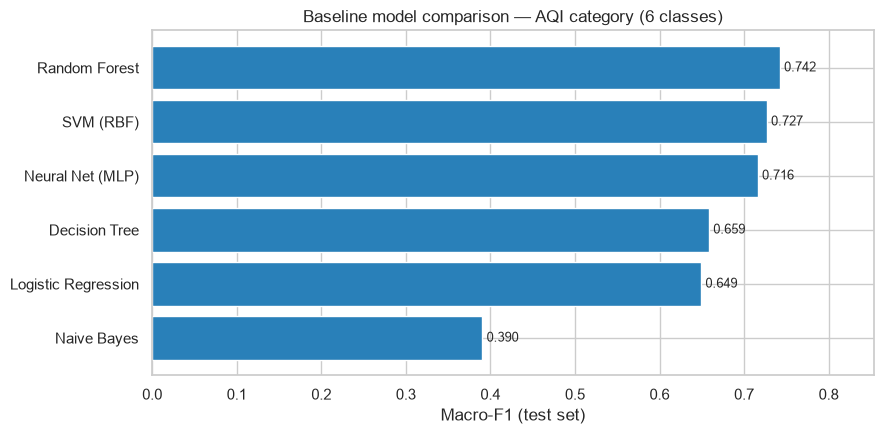

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = baseline_df.sort_values("Macro-F1")
ax.barh(plot_df["Model"], plot_df["Macro-F1"], color="#2980b9")
ax.set_xlabel("Macro-F1 (test set)")
ax.set_title("Baseline model comparison — AQI category (6 classes)")
for i, v in enumerate(plot_df["Macro-F1"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, max(plot_df["Macro-F1"]) * 1.15)
plt.tight_layout(); plt.show()

## 7. Confusion Matrices

The comparison table says *how well*; the confusion matrix says *where it goes wrong*.
For an ordinal target like AQI, we expect most errors to fall on **neighbouring
categories** (e.g. 'Unhealthy' ↔ 'Very Unhealthy') — a mistake of one level is far
less serious than confusing 'Good' with 'Hazardous'.

Best baseline model: Random Forest


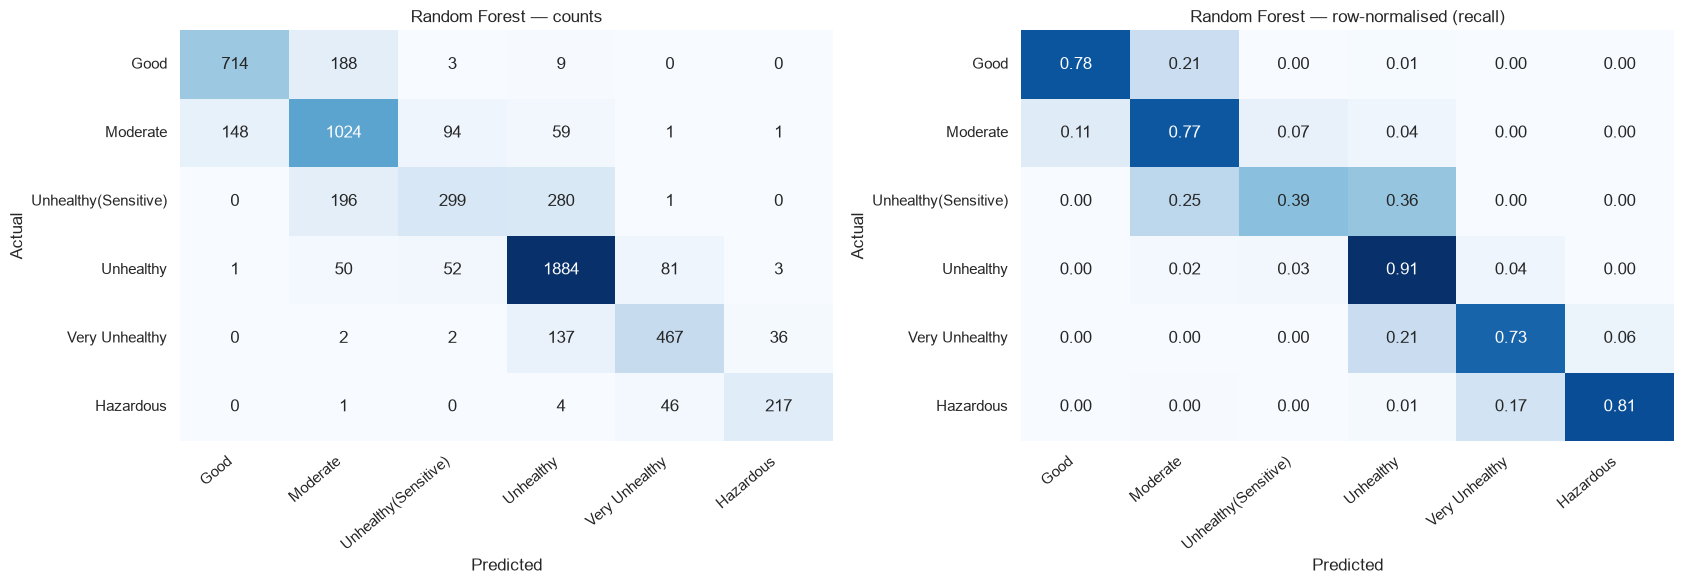

In [10]:
best_baseline = baseline_df.iloc[0]["Model"]
print("Best baseline model:", best_baseline)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
plot_confusion(y_test, baseline_preds[best_baseline],
               f"{best_baseline} — counts", ax=axes[0])
plot_confusion(y_test, baseline_preds[best_baseline],
               f"{best_baseline} — row-normalised (recall)", normalize=True, ax=axes[1])
plt.tight_layout(); plt.show()

### Per-class report
Macro-F1 hides which specific classes struggle — this breaks it down.

In [10]:
print(f"Classification report — {best_baseline}\n")
print(classification_report(y_test, baseline_preds[best_baseline],
                            labels=CLASS_ORDER, zero_division=0))

Classification report — Random Forest

                      precision    recall  f1-score   support

                Good       0.83      0.78      0.80       914
            Moderate       0.70      0.77      0.73      1327
Unhealthy(Sensitive)       0.66      0.39      0.49       776
           Unhealthy       0.79      0.91      0.85      2071
      Very Unhealthy       0.78      0.73      0.75       644
           Hazardous       0.84      0.81      0.83       268

            accuracy                           0.77      6000
           macro avg       0.77      0.73      0.74      6000
        weighted avg       0.76      0.77      0.76      6000



### Compare where two very different models fail
Naive Bayes makes strong independence assumptions; Random Forest does not. Putting
their matrices side by side makes the difference concrete.

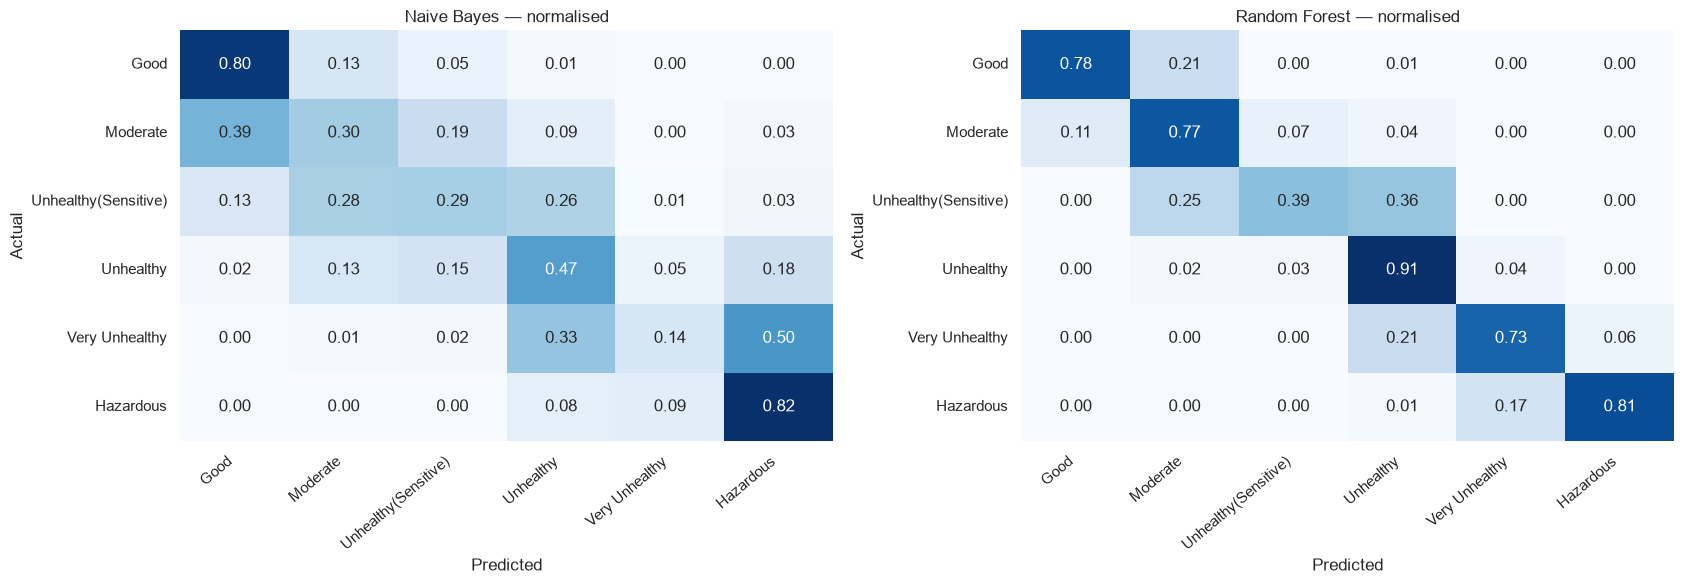

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
plot_confusion(y_test, baseline_preds["Naive Bayes"],
               "Naive Bayes — normalised", normalize=True, ax=axes[0])
plot_confusion(y_test, baseline_preds["Random Forest"],
               "Random Forest — normalised", normalize=True, ax=axes[1])
plt.tight_layout(); plt.show()

## 8. Hyperparameter Tuning (with Cross-Validation)

This is where **Lab 7 (Cross-Validation)** does real work: `GridSearchCV` and
`RandomizedSearchCV` use k-fold CV *internally* to score each candidate, so the
choice of hyperparameters never sees the test set.

**Which search to use:**

| Search | When | Used for |
|---|---|---|
| `GridSearchCV` | small grid — tries every combination | Decision Tree, Logistic Regression |
| `RandomizedSearchCV` | large grid — samples `n_iter` combinations | Random Forest, SVM |

We use **3-fold stratified** CV to keep runtime sensible; 5-fold is also fine on a
faster machine.

In [12]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
tuned_results, tuned_preds, best_params = [], {}, {}

def tune(name, model, param_grid, search="grid", n_iter=6,
         X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test):
    pipe = Pipeline([("pre", build_preprocessor()), ("model", model)])
    Search = GridSearchCV if search == "grid" else RandomizedSearchCV
    kwargs = dict(estimator=pipe, scoring="f1_macro", cv=cv, n_jobs=-1)
    if search == "grid":
        srch = Search(param_grid=param_grid, **kwargs)
    else:
        srch = Search(param_distributions=param_grid, n_iter=n_iter,
                      random_state=RANDOM_STATE, **kwargs)
    t0 = time.time(); srch.fit(X_tr, y_tr); elapsed = time.time() - t0

    y_pred = srch.best_estimator_.predict(X_te)
    res = {"Model": name + " (tuned)",
           "Accuracy":  accuracy_score(y_te, y_pred),
           "Precision": precision_score(y_te, y_pred, average="macro", zero_division=0),
           "Recall":    recall_score(y_te, y_pred, average="macro", zero_division=0),
           "Macro-F1":  f1_score(y_te, y_pred, average="macro", zero_division=0),
           "Fit (s)":   round(elapsed, 1)}
    print(f"{name}: best CV macroF1={srch.best_score_:.3f} | test macroF1={res['Macro-F1']:.3f} | {elapsed:.0f}s")
    print("   best params:", srch.best_params_)
    return res, y_pred, srch.best_params_, srch.best_estimator_

print("Tuning helper ready.")

Tuning helper ready.


### 8.1 Decision Tree — `GridSearchCV`

In [13]:
grid_dt = {
    "model__max_depth":         [6, 10, 16, None],
    "model__min_samples_leaf":  [1, 5, 20],
}
res, pred, bp, dt_best = tune("Decision Tree", DecisionTreeClassifier(random_state=RANDOM_STATE), grid_dt)
tuned_results.append(res); tuned_preds["Decision Tree (tuned)"] = pred; best_params["Decision Tree"] = bp

Decision Tree: best CV macroF1=0.680 | test macroF1=0.698 | 3s
   best params: {'model__max_depth': 10, 'model__min_samples_leaf': 20}


### 8.2 Logistic Regression — `GridSearchCV`

In [14]:
grid_lr = {"model__C": [0.01, 0.1, 1.0, 10.0]}
res, pred, bp, lr_best = tune("Logistic Regression",
                              LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), grid_lr)
tuned_results.append(res); tuned_preds["Logistic Regression (tuned)"] = pred; best_params["Logistic Regression"] = bp

Logistic Regression: best CV macroF1=0.645 | test macroF1=0.651 | 1s
   best params: {'model__C': 10.0}


### 8.3 Random Forest — `RandomizedSearchCV`
The RF grid is large (depth × features × leaf size × trees), so random search over
`n_iter` candidates is the efficient choice.

In [15]:
grid_rf = {
    "model__n_estimators":     [100, 200, 300],
    "model__max_depth":        [10, 20, None],
    "model__max_features":     ["sqrt", "log2"],
    "model__min_samples_leaf": [1, 2, 5],
}
res, pred, bp, rf_best = tune("Random Forest",
                              RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
                              grid_rf, search="random", n_iter=6)
tuned_results.append(res); tuned_preds["Random Forest (tuned)"] = pred; best_params["Random Forest"] = bp

Random Forest: best CV macroF1=0.717 | test macroF1=0.742 | 4s
   best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20}


### 8.4 SVM — `RandomizedSearchCV` on a reduced subset

SVM is the one genuinely expensive model. Because each CV fit is O(n²), we tune on a
**smaller stratified subset** and then report on the same test set. This is a
deliberate, documented trade-off — and exactly the kind of decision worth explaining
in your report.

In [16]:
svm_train = stratified_sample(
    pd.concat([X_train, y_train], axis=1), TARGET, 8_000)
X_svm, y_svm = svm_train[NUMERIC_FEATURES + CATEGORICAL_FEATURES], svm_train[TARGET]
print("SVM tuning subset:", X_svm.shape)

grid_svm = {"model__C": [0.5, 1, 5, 10], "model__gamma": ["scale", 0.01, 0.1]}
res, pred, bp, svm_best = tune("SVM (RBF)", SVC(kernel="rbf", random_state=RANDOM_STATE),
                               grid_svm, search="random", n_iter=4,
                               X_tr=X_svm, y_tr=y_svm)
tuned_results.append(res); tuned_preds["SVM (RBF) (tuned)"] = pred; best_params["SVM (RBF)"] = bp

SVM tuning subset: (8000, 17)
SVM (RBF): best CV macroF1=0.680 | test macroF1=0.698 | 2s
   best params: {'model__gamma': 0.01, 'model__C': 10}


> **Note on the neural network.** MLP tuning (`hidden_layer_sizes`, `alpha`,
> `learning_rate_init`) follows the identical pattern but is the slowest search, so
> it is left as an extension. On your own machine, add:
> ```python
> grid_mlp = {"model__hidden_layer_sizes": [(64,32), (128,64)],
>             "model__alpha": [1e-4, 1e-3]}
> tune("Neural Net (MLP)", MLPClassifier(max_iter=300, random_state=42),
>      grid_mlp, search="random", n_iter=3)
> ```

## 9. ⭐ Handling Class Imbalance

The AQI target is markedly imbalanced — 'Hazardous' is 4.5% of the data while
'Unhealthy' is 34.5%. So far we have *measured* around this (stratified splits,
macro-F1). Now we **actively rebalance** and test whether it helps.

Three standard families, all applied to the same Random Forest so the comparison is fair:

| Strategy | Mechanism | Cost |
|---|---|---|
| **`class_weight='balanced'`** | penalise minority errors more heavily in the loss | free — no new data |
| **SMOTE** (oversampling) | synthesise new minority examples by interpolating neighbours | slower; invents data |
| **Random undersampling** | discard majority examples until classes match | fast; throws data away |

> ### 🔑 Why resampling must live *inside* the Pipeline
> Resampling before splitting is a classic leakage bug: SMOTE would generate synthetic
> points from test-set neighbours, and duplicated minority rows could land in both
> train and test. `imblearn.Pipeline` applies resampling **only to the training fold**
> and leaves validation/test data untouched. This is exactly why we use it instead of
> calling `SMOTE().fit_resample()` on the whole dataset first.

In [17]:
def rf(**kwargs):
    return RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                  random_state=RANDOM_STATE, **kwargs)

balance_strategies = {
    "No balancing (baseline)": Pipeline([("pre", build_preprocessor()),
                                         ("model", rf())]),
    "class_weight='balanced'": Pipeline([("pre", build_preprocessor()),
                                         ("model", rf(class_weight="balanced"))]),
    "SMOTE oversampling":      ImbPipeline([("pre", build_preprocessor()),
                                            ("smote", SMOTE(random_state=RANDOM_STATE)),
                                            ("model", rf())]),
    "Random undersampling":    ImbPipeline([("pre", build_preprocessor()),
                                            ("under", RandomUnderSampler(random_state=RANDOM_STATE)),
                                            ("model", rf())]),
}

bal_rows, bal_preds = [], {}
for name, pipe in balance_strategies.items():
    t0 = time.time(); pipe.fit(X_train, y_train); el = time.time() - t0
    yp = pipe.predict(X_test)
    bal_preds[name] = yp
    recalls = recall_score(y_test, yp, average=None, labels=CLASS_ORDER, zero_division=0)
    bal_rows.append({
        "Strategy":   name,
        "Accuracy":   accuracy_score(y_test, yp),
        "Macro-F1":   f1_score(y_test, yp, average="macro", zero_division=0),
        "Recall: Hazardous":      recalls[CLASS_ORDER.index("Hazardous")],
        "Recall: Very Unhealthy": recalls[CLASS_ORDER.index("Very Unhealthy")],
        "Fit (s)":    round(el, 1),
    })
    print(f"{name:26s} macroF1={bal_rows[-1]['Macro-F1']:.3f}  "
          f"Hazardous-recall={bal_rows[-1]['Recall: Hazardous']:.3f}  ({el:.0f}s)")

bal_df = pd.DataFrame(bal_rows)
bal_df.round(3)

No balancing (baseline)    macroF1=0.742  Hazardous-recall=0.810  (0s)
class_weight='balanced'    macroF1=0.753  Hazardous-recall=0.877  (0s)
SMOTE oversampling         macroF1=0.748  Hazardous-recall=0.869  (1s)
Random undersampling       macroF1=0.706  Hazardous-recall=0.918  (0s)


,Strategy,Accuracy,Macro-F1,Recall: Hazardous,Recall: Very Unhealthy,Fit (s)
0,No balancing (baseline),0.768,0.742,0.810,0.725,0.3
1,class_weight='balanced',0.755,0.753,0.877,0.837,0.3
2,SMOTE oversampling,0.755,0.748,0.869,0.784,0.8
3,Random undersampling,0.695,0.706,0.918,0.817,0.2


### Comparing the strategies visually
Two things matter: overall quality (**macro-F1**) and how well we catch the rarest,
most dangerous class (**recall on 'Hazardous'**).

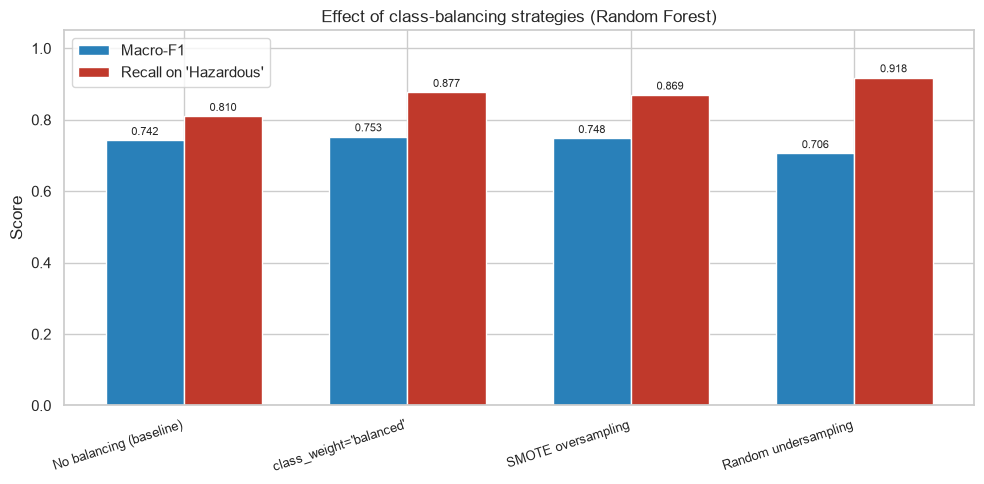

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(bal_df)); w = 0.35
ax.bar(x - w/2, bal_df["Macro-F1"], w, label="Macro-F1", color="#2980b9")
ax.bar(x + w/2, bal_df["Recall: Hazardous"], w, label="Recall on 'Hazardous'", color="#c0392b")
ax.set_xticks(x)
ax.set_xticklabels(bal_df["Strategy"], rotation=18, ha="right", fontsize=9)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("Effect of class-balancing strategies (Random Forest)")
for i, (f1v, rc) in enumerate(zip(bal_df["Macro-F1"], bal_df["Recall: Hazardous"])):
    ax.text(i - w/2, f1v + 0.015, f"{f1v:.3f}", ha="center", fontsize=8)
    ax.text(i + w/2, rc + 0.015, f"{rc:.3f}", ha="center", fontsize=8)
ax.legend()
plt.tight_layout(); plt.show()

### Confusion matrices — before and after balancing
The clearest way to see what balancing bought us: look at the bottom rows, where the
rare classes live.

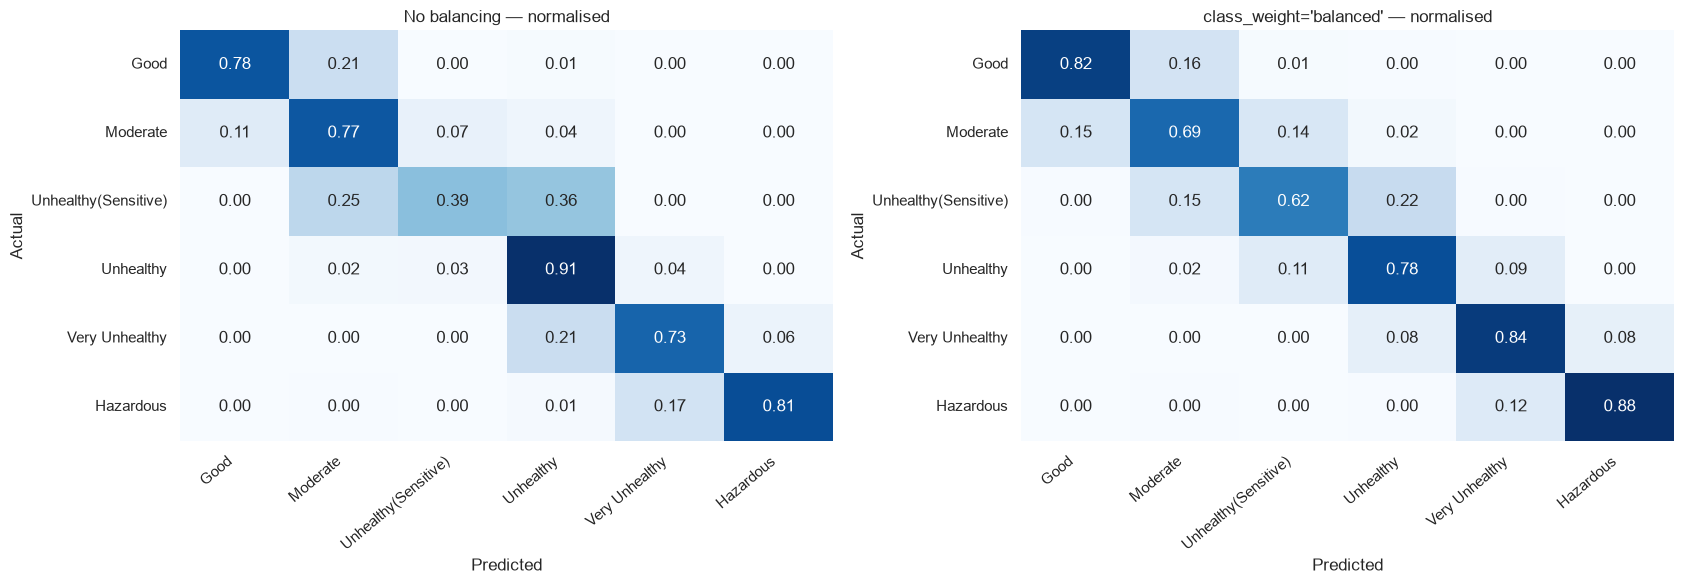

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
plot_confusion(y_test, bal_preds["No balancing (baseline)"],
               "No balancing — normalised", normalize=True, ax=axes[0])
plot_confusion(y_test, bal_preds["class_weight='balanced'"],
               "class_weight='balanced' — normalised", normalize=True, ax=axes[1])
plt.tight_layout(); plt.show()

> ### 📌 Verdict — `class_weight='balanced'` wins
>
> - **`class_weight='balanced'` improved *both* metrics at zero computational cost** —
>   macro-F1 rose and recall on 'Hazardous' rose substantially. When a free change
>   improves everything, take it.
> - **SMOTE matched it almost exactly but took ~3× longer.** Synthesising minority
>   points achieved nothing that reweighting the loss did not already achieve — worth
>   reporting, because SMOTE is often applied reflexively.
> - **Random undersampling bought the highest minority recall but the worst macro-F1.**
>   It discards the majority of the data, so overall performance degrades. It is the
>   right choice *only* if missing a hazardous hour is catastrophic and false alarms are
>   nearly free.
>
> **The general lesson for your report:** balancing is a *trade*, not a free upgrade.
> Undersampling makes the trade explicit and costly; class weighting made it cheaply
> here because Random Forest's loss responds well to reweighting. Always try the free
> option (`class_weight`) before the expensive one (SMOTE).

## 10. Ensemble Model (Lab 11)

A **soft-voting** ensemble averages the predicted probabilities of several tuned
models. The idea: different algorithms make different mistakes, so combining them
can beat any single one. We use the tuned Decision Tree, Logistic Regression and
Random Forest.

In [20]:
voting = VotingClassifier(
    estimators=[
        ("dt", dt_best.named_steps["model"]),
        ("lr", lr_best.named_steps["model"]),
        ("rf", rf_best.named_steps["model"]),
    ],
    voting="soft", n_jobs=-1)

pipe_vote = Pipeline([("pre", build_preprocessor()), ("model", voting)])
res, pred = evaluate("Voting Ensemble", pipe_vote, X_train, y_train, X_test, y_test)
tuned_results.append(res); tuned_preds["Voting Ensemble"] = pred

Voting Ensemble        acc=0.754  macroF1=0.726  (1.1s)


## 11. Feature Importance (Random Forest)

Which measurements actually drive the prediction? This is one of the most
report-worthy outputs — it turns a model into an *insight*.

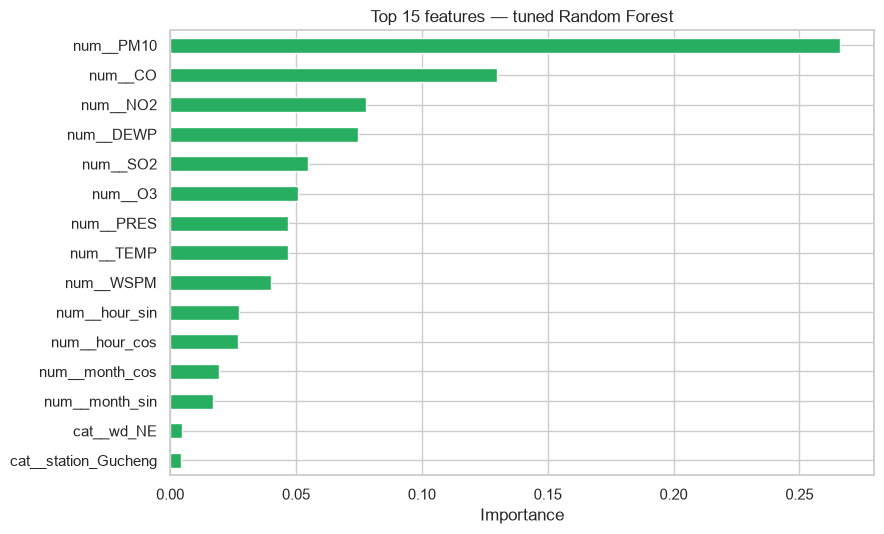

In [21]:
rf_model = rf_best.named_steps["model"]
feat_names = rf_best.named_steps["pre"].get_feature_names_out()

imp = (pd.Series(rf_model.feature_importances_, index=feat_names)
         .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 5.5))
imp.sort_values().plot(kind="barh", color="#27ae60", ax=ax)
ax.set_title("Top 15 features — tuned Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()

## 12. Final Comparison — Baseline vs Tuned

In [22]:
final_df = (pd.concat([baseline_df, pd.DataFrame(tuned_results)], ignore_index=True)
              .sort_values("Macro-F1", ascending=False)
              .reset_index(drop=True))
final_df.round(3)

,Model,Accuracy,Precision,Recall,Macro-F1,Fit (s)
0,Random Forest,0.768,0.769,0.730,0.742,0.3
1,Random Forest (tuned),0.768,0.774,0.727,0.742,4.2
2,SVM (RBF),0.746,0.741,0.717,0.727,3.9
3,Voting Ensemble,0.754,0.749,0.716,0.726,1.1
4,Neural Net (MLP),0.726,0.713,0.721,0.716,8.2
5,SVM (RBF) (tuned),0.722,0.706,0.694,0.698,1.6
6,Decision Tree (tuned),0.716,0.702,0.698,0.698,2.7
7,Decision Tree,0.668,0.656,0.661,0.659,0.2
8,Logistic Regression (tuned),0.693,0.679,0.642,0.651,0.7
9,Logistic Regression,0.693,0.679,0.640,0.649,0.3


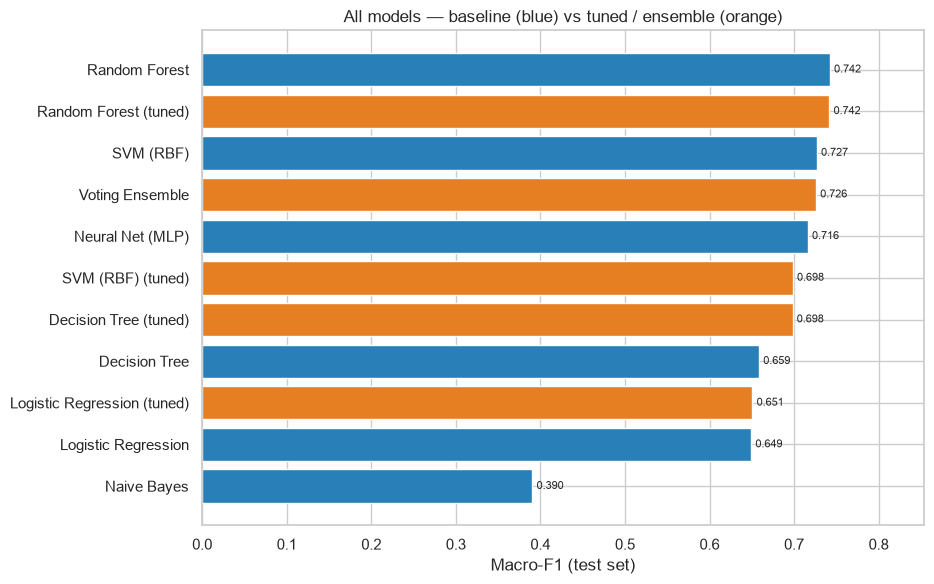

In [23]:
fig, ax = plt.subplots(figsize=(9.5, 6))
d = final_df.sort_values("Macro-F1")
colors = ["#e67e22" if "tuned" in m or "Ensemble" in m else "#2980b9" for m in d["Model"]]
ax.barh(d["Model"], d["Macro-F1"], color=colors)
ax.set_xlabel("Macro-F1 (test set)")
ax.set_title("All models — baseline (blue) vs tuned / ensemble (orange)")
for i, v in enumerate(d["Macro-F1"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlim(0, max(d["Macro-F1"]) * 1.15)
plt.tight_layout(); plt.show()

### Confusion matrix of the overall best model

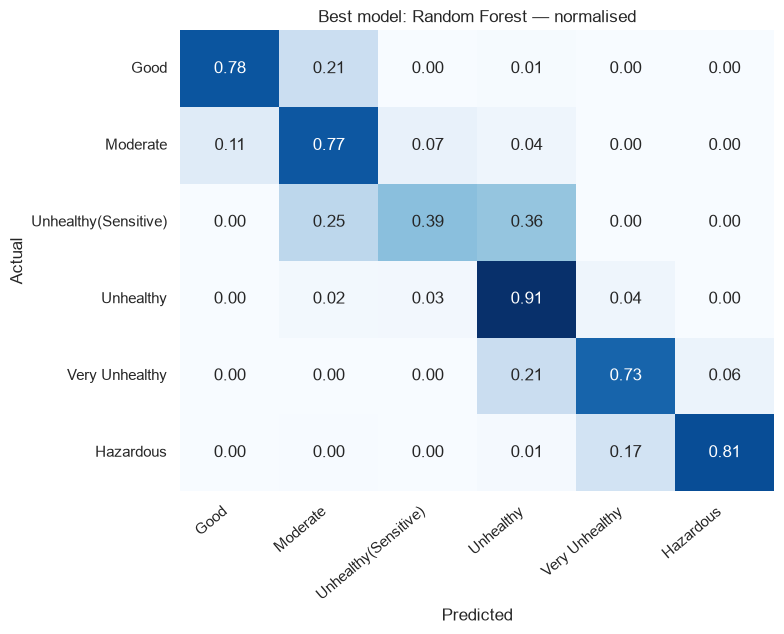


Best model: Random Forest
Accuracy     0.768
Precision    0.769
Recall        0.73
Macro-F1     0.742


In [24]:
best_overall = final_df.iloc[0]["Model"]
all_preds = {**baseline_preds, **tuned_preds}
pred_best = all_preds[best_overall]

plot_confusion(y_test, pred_best, f"Best model: {best_overall} — normalised", normalize=True)
plt.tight_layout(); plt.show()

print(f"\nBest model: {best_overall}")
print(final_df.iloc[0][["Accuracy","Precision","Recall","Macro-F1"]].round(3).to_string())

### Best hyperparameters found

In [25]:
for model, params in best_params.items():
    clean = {k.replace("model__", ""): v for k, v in params.items()}
    print(f"{model:22s} {clean}")

Decision Tree          {'max_depth': 10, 'min_samples_leaf': 20}
Logistic Regression    {'C': 10.0}
Random Forest          {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
SVM (RBF)              {'gamma': 0.01, 'C': 10}


## Summary & What's Next

**Covered in this notebook:**
- Seven algorithms (Naive Bayes, Logistic Regression, Decision Tree, Random Forest,
  SVM, MLP, Voting Ensemble) on the 6-class AQI target
- A leakage-safe `Pipeline` for every model, with `PM2.5` deliberately excluded
- Consistent evaluation: accuracy, precision, recall, **macro-F1**, confusion matrices,
  per-class report
- **Cross-validated hyperparameter tuning** with both `GridSearchCV` and `RandomizedSearchCV`
- Feature importance and a baseline-vs-tuned comparison

**Points worth writing up in your report:**
1. Why macro-F1, not accuracy, is the right headline metric under class imbalance.
2. Why `PM2.5` had to be excluded — and what would have happened if it weren't.
3. That most confusion happens between *adjacent* AQI levels, which is the benign
   kind of error for an ordinal target.
4. The SVM sampling trade-off — an algorithmic constraint (O(n²)), not a hardware one.

**Next — Notebook 03: Binary Classification** ('Unhealthy day?'), which adds
ROC curves, AUC and threshold analysis on top of this same framework.
